#### Imports

In [ ]:
import importlib
import time
import copy
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import heapq
import pickle
import random

from joblib import Parallel, delayed

from sklearn.model_selection import train_test_split
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C, WhiteKernel
from sklearn.gaussian_process.kernels import RBF, Matern, RationalQuadratic, WhiteKernel, ConstantKernel as C, DotProduct
from sklearn.gaussian_process import GaussianProcessRegressor

import globals
import utils

np.set_printoptions(precision=4, suppress=True, linewidth=np.inf, threshold=np.inf)

pd.set_option("display.width", 1000)
pd.set_option("display.max_columns", None)

seed = 42
random.seed(seed)
np.random.seed(seed)

In [99]:
importlib.reload(globals)
importlib.reload(utils)

<module 'utils' from 'c:\\Users\\Matteo\\Desktop\\Scuola\\MastersThesis\\Master_Thesis\\utils.py'>

In [100]:
param_names, function_names = utils.inspect_metadata(globals.CURRENT_TRAIN_FILE)

Keys in train_file: ['I0', 'LUTdata', 'LUTheader', 'dynamic', 'static', 'wvl']

Attributes in LUTheader (inputs):
  varnames: O3STR,H2OSTR,VIS,G,ASTMX,SSA,PARM2,OBSZEN,PARM1

Attributes in train_file (outputs):
  RTMname: MODTRAN6
  inputmode: Latin hypercube
  lut_package_date: 10-Apr-2025
  opmode: Transfer Functions
  outnames: Lp0,Edir0,Edif0,S,tdir,tdif
  sensor: Empty(dtype=dtype('O'))

LUTheader shape: (500, 9)
LUTdata shape: (500, 25230)
wvl shape: (1, 4205)


In [101]:
param_names_plots = ['Ozone (atm-cm)', 'Columnar Water Vapor (g/cm^2)', 'Aerosol Optical Depth (-)', 'Asymmetry Parameter (-)', 'Angstrom Exponent (-)',
                     'Single Scattering Albedo (-)', 'Solar Zenith Angle (deg)', 'View Zenith Angle (deg)', 'Relative Azimuth Angle (deg)']
param_names_plots_abb = ['O3', 'CWV', 'AOD', 'Asy. Param.', 'Ang. Exp.', 'SSA', 'SZA', 'VZA', 'RAA']

function_names_plots = ['Path Radiance', 'Direct Solar Irradiance', 'Diffuse Solar Irradiance', 'Spherical Albedo', 'Direct Transmittance', 'Diffuse Transmittance']
function_names_plots_abb = ['Path Rad.', 'Direct Irrad.', 'Diffuse Irrad.', 'Sph. Alb.', 'Direct Trans.', 'Diffuse Trans.']

In [102]:
X, Y, wavelengths = utils.load_train_h5(globals.CURRENT_TRAIN_FILE)
wavelengths = wavelengths.squeeze()
Y_resh = Y.reshape(-1, Y.shape[1] // len(wavelengths), len(wavelengths))

# first split: train (80%) and temp (20%)
X_tr, X_temp, Y_tr, Y_temp = train_test_split(X, Y_resh, test_size=0.2, shuffle=True, random_state=42)

# second split: validation (10%) and test (10%)
X_val, X_test, Y_val, Y_test = train_test_split(X_temp, Y_temp, test_size=0.5, shuffle=True, random_state=42)

print("X shape:", X.shape)
print("Y shape:", Y.shape)
print("wavelengths shape:", wavelengths.shape)
print()
print("X_tr shape:", X_tr.shape)
print("X_val shape:", X_val.shape)
print("X_test shape:", X_test.shape)
print()
print("Y_tr shape:", Y_tr.shape)
print("Y_val shape:", Y_val.shape)
print("Y_test shape:", Y_test.shape)

X shape: (500, 9)
Y shape: (500, 25230)
wavelengths shape: (4205,)

X_tr shape: (400, 9)
X_val shape: (50, 9)
X_test shape: (50, 9)

Y_tr shape: (400, 6, 4205)
Y_val shape: (50, 6, 4205)
Y_test shape: (50, 6, 4205)


#### Gaussian Process Pipeline

<ol>
    <li><b>Dimensionality Reduction</b>: PCA and Kernel PCA are implemented to reduce the outputs.</li>
    <li><b>Scaling</b>: standard scaling and min-max scaling are implemented to scale inputs and outputs.</li>
    <li><b>Fit</b> of the Gaussian Processes.</li>
    <li><b>Validation</b> of the Gaussian Processes.</li>
    <li><b>External Testing</b> of the Gaussian Processes.</li>
</ol>

In [103]:
# PARALLELIZATION OF GP FITTING FOR LARGER DATASETS - DOESN'T PRINT INFO, SO NOT USED FOR NOW
# def _fit_single_gp(i, x_tr_scaled, y_tr_reduced_scaled, gp_kernel):
#     gpr = GaussianProcessRegressor(kernel=copy.deepcopy(gp_kernel), n_restarts_optimizer=0, random_state=42)

#     gpr.fit(x_tr_scaled, y_tr_reduced_scaled[:, i, :])

#     print("Learned kernel:", gpr.kernel_)

#     return gpr


# def fit_gp(x_tr_scaled, y_tr_reduced_scaled, gp_kernel):
#     """
#     Fit a Gaussian Process Regressor for each output function. Reduced and scaled data is used to speed up fitting and improve performance
#     - inputs: training inputs, training outputs, GP kernel to use for fitting
#     - outputs: list of fitted GaussianProcessRegressor models for each output function and the time taken to fit all GPs
#     """

#     print("---------- Fitting Gaussian Process Regressor for each output function... ----------")

#     gpr_list = []

#     # start measuring time
#     start_time_fit = time.time()

#     gpr_list = Parallel(n_jobs=12)(
#         delayed(_fit_single_gp)(
#             i,
#             x_tr_scaled,
#             y_tr_reduced_scaled,
#             gp_kernel
#         )
#         for i in range(globals.N_FUNCTIONS)
#     )

#     end_time_fit = time.time()

#     print(f"Time taken to fit GPs: {end_time_fit - start_time_fit:.2f} seconds")

#     print("---------- Gaussian Process fitting completed. ----------\n")

#     return gpr_list, end_time_fit - start_time_fit

In [104]:
def fit_gp(x_tr_scaled, y_tr_reduced_scaled, gp_kernel):
    """
    Fit a Gaussian Process Regressor for each output function. Reduced and scaled data is used to speed up fitting and improve performance
    - inputs: training inputs, training outputs, GP kernel to use for fitting
    - outputs: list of fitted GaussianProcessRegressor models for each output function and the time taken to fit all GPs
    """

    print("---------- Fitting Gaussian Process Regressor for each output function... ----------")

    gpr_list = []
    start_time_fit = time.time()
    for i in range(globals.N_FUNCTIONS):
        # more than 0 restarts causes a huge increase in fitting time without significant improvement in performance
        gpr = GaussianProcessRegressor(kernel=copy.deepcopy(gp_kernel), n_restarts_optimizer=0, random_state=42)
        gpr.fit(x_tr_scaled, y_tr_reduced_scaled[:, i, :])
        print("Learned kernel:", gpr.kernel_)
        gpr_list.append(gpr)
    end_time_fit = time.time()
    print(f"Time taken to fit GPs: {end_time_fit - start_time_fit:.2f} seconds")

    print("---------- Gaussian Process fitting completed. ----------\n")

    return gpr_list, end_time_fit - start_time_fit

In [105]:
def validate_gp(gpr_list, x_val_scaled, y_val, wavelengths, y_scalers, pca_list):
    """
    Validate the fitted Gaussian Process models on the validation set
    - inputs: list of fitted GaussianProcessRegressor models, validation inputs, validation outputs, wavelengths, list of scalers used for each output function, list of PCA objects for each output function
    - outputs: numpy array of predicted outputs on the validation set in the original space (n_samples, 6, 4205)
    """

    print("---------- Validating Gaussian Process models on the validation set... ----------")

    y_val_pred = np.zeros_like(y_val)  # (n_samples, 6, 4205)
    for i in range(globals.N_FUNCTIONS):
        y_pred_red_scaled = gpr_list[i].predict(x_val_scaled) # predictions in reduced and scaled space
        y_pred_red = y_scalers[i].inverse_transform(y_pred_red_scaled)  # inverse scaling
        y_pred = pca_list[i].inverse_transform(y_pred_red)  # inverse PCA
        y_val_pred[:, i, :] = y_pred

    print("y_val_pred shape:", y_val_pred.shape)

    # MRE calculation
    mre = utils.mre_score(y_val, y_val_pred, wavelengths)
    print(f"----- Validation MRE: {mre} -----")

    print("---------- Validation completed. ----------\n")

    return mre

Define kernels to try in the Gaussian Process fit.

In [106]:
n_feat = X_tr.shape[1]

kern_rbf = (
        C(1.0, (1e-3, 1e3)) *
        RBF(length_scale=np.ones(n_feat), length_scale_bounds=(1e-3, 1e3))
        + WhiteKernel(noise_level=1e-2, noise_level_bounds=(1e-5, 1e1))
    )

kern_matern = (
    C(1.0, (1e-3, 1e3))
    * Matern(
        length_scale=np.ones(n_feat),
        length_scale_bounds=(1e-3, 1e3),
        nu=2.5
    )
    + WhiteKernel(1e-2, (1e-5, 1e1))
)

kern_rq = (
    C(1.0, (1e-3, 1e3))
    * RationalQuadratic(
        length_scale=1.0,
        alpha=1.0,
        length_scale_bounds=(1e-3, 1e3),
        alpha_bounds=(1e-3, 1e3)
    )
    + WhiteKernel(1e-2, (1e-5, 1e1))
)

kern_rbf_rq = (
    C(1.0, (1e-3, 1e3))
    * (
        RBF(
            length_scale=np.ones(n_feat),
            length_scale_bounds=(1e-3, 1e3)
        )
        + RationalQuadratic(
            length_scale=1.0,
            alpha=1.0
        )
    )
    + WhiteKernel(1e-2, (1e-5, 1e1))
)

kern_dot_rbf = (
    C(1.0, (1e-3, 1e3))
    * (
        DotProduct()
        + RBF(
            length_scale=np.ones(n_feat),
            length_scale_bounds=(1e-3, 1e3)
        )
    )
    + WhiteKernel(1e-2, (1e-5, 1e1))
)

kern_linear = (
    C(1.0, (1e-3, 1e3))
    * DotProduct()
    + WhiteKernel(1e-2, (1e-5, 1e1))
)

kern_matern_rq = (
    C(1.0, (1e-3, 1e3))
    * (
        Matern(
            length_scale=np.ones(n_feat),
            nu=1.5
        )
        + RationalQuadratic()
    )
    + WhiteKernel(1e-2, (1e-5, 1e1))
)

Apply the whole pipeline.

In [ ]:
# param_grid = {
#     "kernel": [None, "rbf", "sigmoid", "poly"],
#     "gamma": [1e-5, 1e-4, 1e-3, 1e-2, 1e-1],
#     "alpha": [1e-3, 1e-2, 1e-1, 1],
#     "degree": [2, 3, 4],
#     "scale_type": ["standard", "minmax"]
# }
param_grid = { # for quick testing
    "pca_kernel": [None],
    "gamma": [1e-2],
    "alpha": [1e-1],
    "degree": [3],
    "scale_type": ["standard", "minmax"],
    "gp_kernel": [kern_rbf, kern_matern, kern_rq, kern_rbf_rq, kern_dot_rbf, kern_linear, kern_matern_rq]
}

last_id = utils.load_csv_last_id("./gp_saves/gp_results.csv")
top_results = []

for pca_kernel in param_grid["pca_kernel"]:

    # if regular PCA is used, gamma and alpha are irrelevant
    if pca_kernel is None:
        gamma_values = [None]
        alpha_values = [None]
    else:
        gamma_values = param_grid["gamma"]
        alpha_values = param_grid["alpha"]

    # if the kernel is not polynomial, degree is irrelevant
    if pca_kernel != "poly":
        degree_values = [0]
    else:
        degree_values = param_grid["degree"]

    for gamma in gamma_values:
        for alpha in alpha_values:
            for degree in degree_values:
                for scale_type in param_grid["scale_type"]:
                    for gp_kernel in param_grid["gp_kernel"]:
                        start_time_pipeline = time.time()
                        gp_kernel_name = str(gp_kernel).replace(" ", "")
                        print(f"========== Running GP pipeline with pca_kernel={pca_kernel}, gamma={gamma}, alpha={alpha}, degree={degree}, scale_type={scale_type} and gp_kernel={gp_kernel_name}... ==========")

                        # dimensionality reduction
                        pca_list, Y_tr_pca, _ = utils.apply_pca(Y_tr, Y_val, n_components=10, kernel=pca_kernel, gamma=gamma, alpha=alpha, degree=degree)

                        # scaling
                        x_scaler, X_tr_scaled, X_val_scaled = utils.scale_input_data(X_tr, X_val, scale_type=scale_type)
                        y_scalers, Y_tr_reduced_scaled, _ = utils.scale_output_data(Y_tr_pca, _, scale_type=scale_type)

                        # fit Gaussian Process
                        gpr_list, gp_fit_time = fit_gp(X_tr_scaled, Y_tr_reduced_scaled, gp_kernel)

                        # validate Gaussian Process
                        mre = validate_gp(gpr_list, X_val_scaled, Y_val, wavelengths, y_scalers, pca_list)
                        end_time_pipeline = time.time()

                        # keep only best 5 models based on MRE
                        entry = (mre, {
                            "pca_kernel": pca_kernel,
                            "gamma": gamma,
                            "alpha": alpha,
                            "degree": degree,
                            "scale_type": scale_type,
                            "gp_kernel": gp_kernel_name
                        }, gpr_list, pca_list, x_scaler, y_scalers)

                        heapq.heappush(top_results, entry)
                        top_results = heapq.nsmallest(5, top_results, key=lambda x: x[0])

                        # write parameters and MRE to csv file
                        results_df = pd.DataFrame({
                            "id": [last_id + 1],
                            "pca_kernel": [pca_kernel if pca_kernel is not None else "None"],
                            "gamma": [gamma if gamma is not None else "None"],
                            "alpha": [alpha if alpha is not None else "None"],
                            "degree": [degree if degree != 0 else "None"],
                            "scale_type": [scale_type],
                            "gp_kernel": [gp_kernel_name],
                            "fit_time": [gp_fit_time],
                            "total_time": [end_time_pipeline - start_time_pipeline],
                            "mre": [mre]
                        })
                        results_df.to_csv("./gp_saves/gp_results.csv", mode="a", header=not Path("./gp_saves/gp_results.csv").exists(), index=False)
                        last_id += 1
                        print("================================================== GP pipeline completed. ==================================================\n")

# save top results in pickle
with open("./gp_saves/top_gp_results.pkl", "wb") as f:
    pickle.dump(top_results, f)

In [ ]:
# load and analyze csv results
df_results = pd.read_csv("./gp_saves/gp_results.csv")

# ordered barplot of MRE for each parameter combination
df_results = df_results.sort_values(by="mre")
print("Best 5 parameter combinations based on MRE:")
df_results.head(5)

Best 5 parameter combinations based on MRE:


,id,pca_kernel,gamma,alpha,degree,scale_type,gp_kernel,fit_time,total_time,mre
8,9,NaN,NaN,NaN,NaN,minmax,"1**2*Matern(length_scale=[1,1,1,1,1,1,1,1,1],n...",12.194269,12.286577,0.002448
1,2,NaN,NaN,NaN,NaN,standard,"1**2*Matern(length_scale=[1,1,1,1,1,1,1,1,1],n...",15.841663,15.933674,0.002574
7,8,NaN,NaN,NaN,NaN,minmax,"1**2*RBF(length_scale=[1,1,1,1,1,1,1,1,1])+Whi...",9.360080,9.451062,0.003052
10,11,NaN,NaN,NaN,NaN,minmax,"1**2*RBF(length_scale=[1,1,1,1,1,1,1,1,1])+Rat...",26.143948,26.238033,0.003089
11,12,NaN,NaN,NaN,NaN,minmax,1**2*DotProduct(sigma_0=1)+RBF(length_scale=[1...,21.028615,21.118627,0.003124


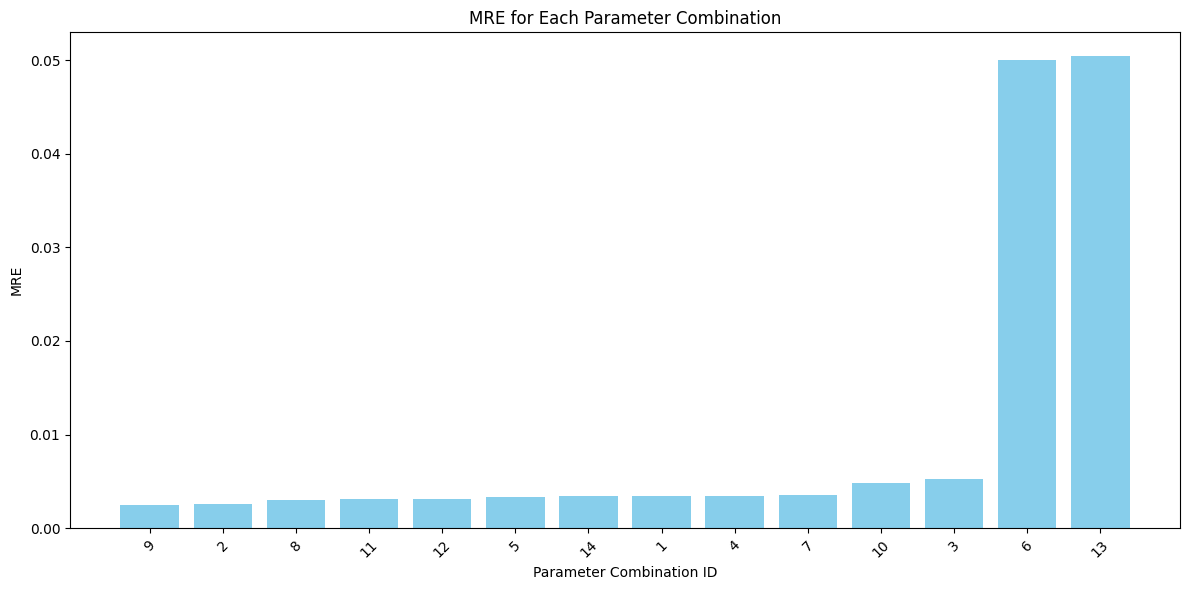

In [10]:
plt.figure(figsize=(12, 6))
plt.bar(range(len(df_results)), df_results["mre"], color="skyblue")
plt.xlabel("Parameter Combination ID")
plt.ylabel("MRE")
plt.title("MRE for Each Parameter Combination")
plt.xticks(range(len(df_results)), df_results["id"], rotation=45)
plt.tight_layout()
plt.show()

Further testing: global average MRE, MRE for each function, MRE for each wavelength, MRE for each function for each wavelength on the external test set.

In [ ]:
top_results = pickle.load(open("./gp_saves/top_gp_results.pkl", "rb"))
best_5_mre = [r[0] for r in top_results]
best_5_parameters = [r[1] for r in top_results]
best_5_gpr_lists = [r[2] for r in top_results]
best_5_pca_lists = [r[3] for r in top_results]
best_5_x_scalers = [r[4] for r in top_results]
best_5_y_scalers = [r[5] for r in top_results]

In [12]:
# predict on test set with chosen model
idx = 0 # index of the model to use for test prediction (0 to 4)
Y_test_pred = np.zeros_like(Y_test)  # (n_samples, 6, 4205)
Y_test_std = np.zeros_like(Y_test)  # (n_samples, 6, 4205)

X_test_scaled = best_5_x_scalers[idx].transform(X_test) # scale test inputs with the same scaler used for training

for i in range(globals.N_FUNCTIONS):
    # 1. get latent predictions and uncertainty
    # y_pred_red_scaled: (n_samples, n_components)
    # y_std_red_scaled:  (n_samples, n_components)
    Y_pred_red_scaled, Y_std_red_scaled = best_5_gpr_lists[idx][i].predict(X_test_scaled, return_std=True)

    # 2. inverse Scaling
    Y_pred_red = best_5_y_scalers[idx][i].inverse_transform(Y_pred_red_scaled)
    
    # scale the standard deviation based on the scaler type
    if str(best_5_y_scalers[idx][i]) == "StandardScaler()":
        Y_std_red = Y_std_red_scaled * best_5_y_scalers[idx][i].scale_
    else: # MinMaxScaler
        Y_std_red = Y_std_red_scaled * (best_5_y_scalers[idx][i].data_max_ - best_5_y_scalers[idx][i].data_min_)

    # 3. inverse PCA reconstruction
    Y_pred = best_5_pca_lists[idx][i].inverse_transform(Y_pred_red)

    # 4. propagate variance through PCA
    # W is the components matrix: (n_components, n_wavelengths)
    W = best_5_pca_lists[idx][i].components_
    
    # variance in original space: Var(Y) = W^T * Var(Z) * W 
    # since components are treated as independent, this simplifies:
    # Y_std_full[wavelength] = sqrt( sum( W[comp, wavelength]^2 * latent_var[comp] ) )
    latent_var = Y_std_red**2  # shape (n_samples, n_components)

    # matrix multiplication to get variance per wavelength: (n_samples, n_wavelengths)
    # (n_samples, n_components) @ (n_components, n_wavelengths)
    Y_var_full = latent_var @ (W**2)
    Y_std_full = np.sqrt(Y_var_full)

    # 5. store results
    Y_test_pred[:, i, :] = Y_pred
    Y_test_std[:, i, :] = Y_std_full

Testing MRE: 0.002302318
Path Radiance MRE: 0.0056
Direct Solar Irradiance MRE: 0.0011
Diffuse Solar Irradiance MRE: 0.0025
Spherical Albedo MRE: 0.0025
Direct Transmittance MRE: 0.0002
Diffuse Transmittance MRE: 0.0019


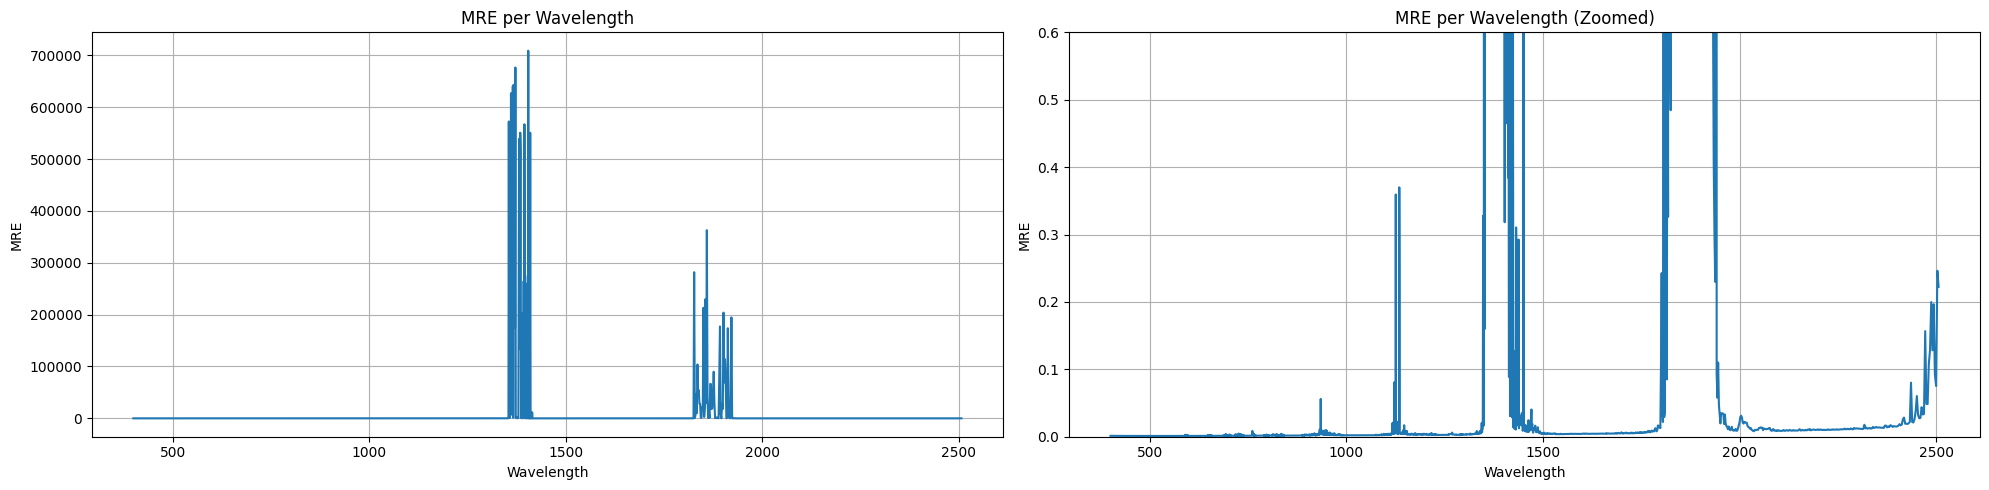

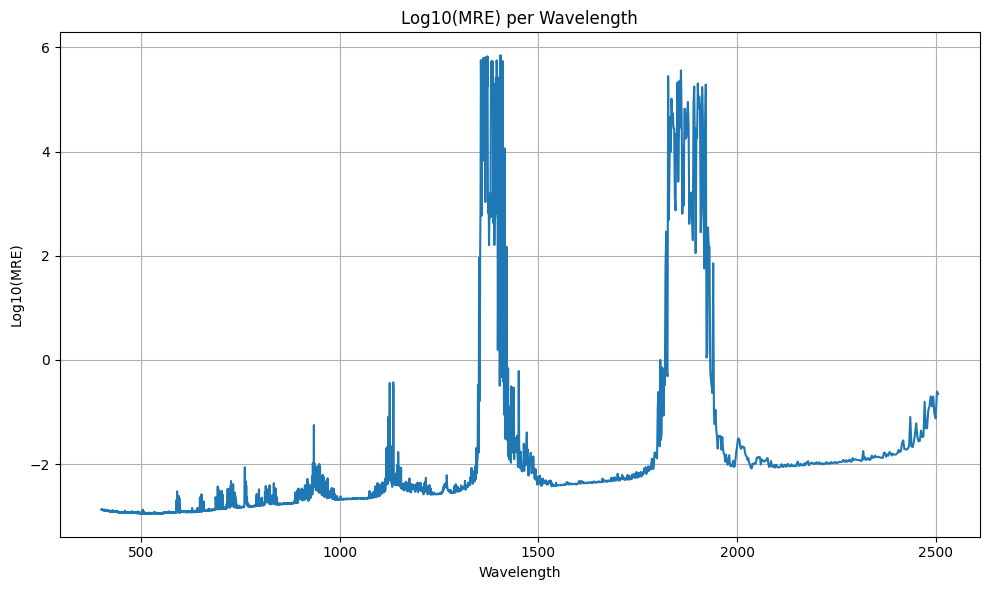

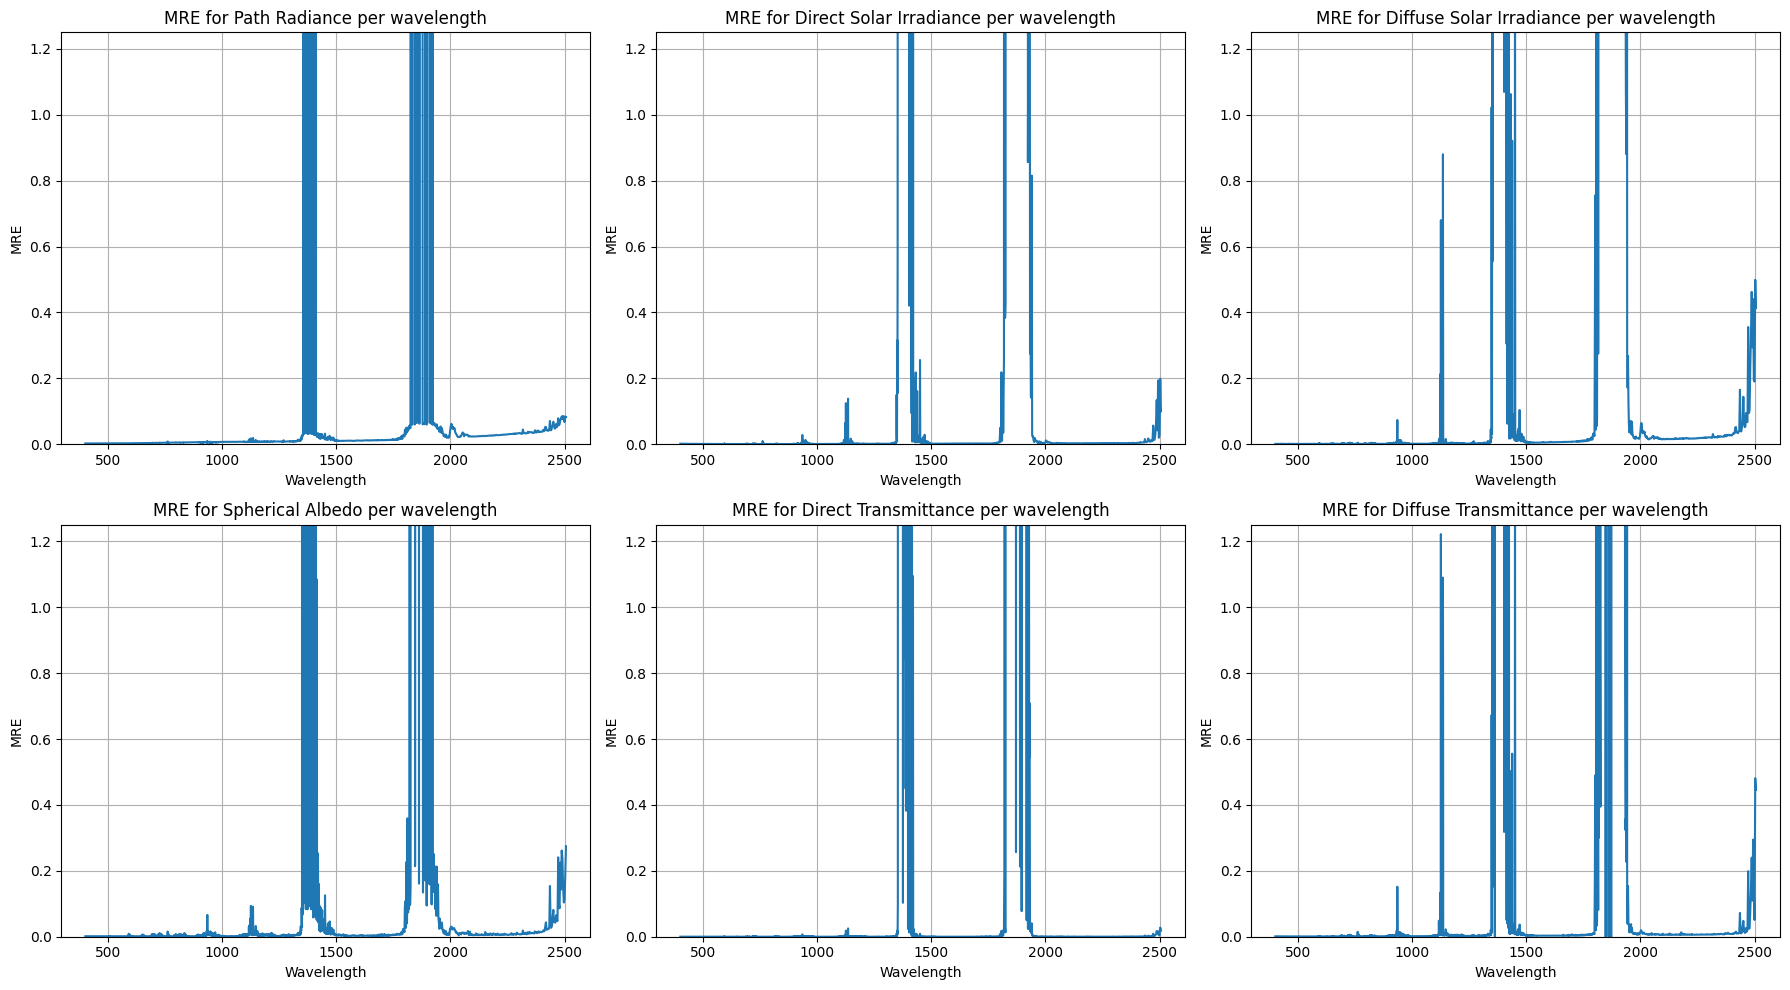

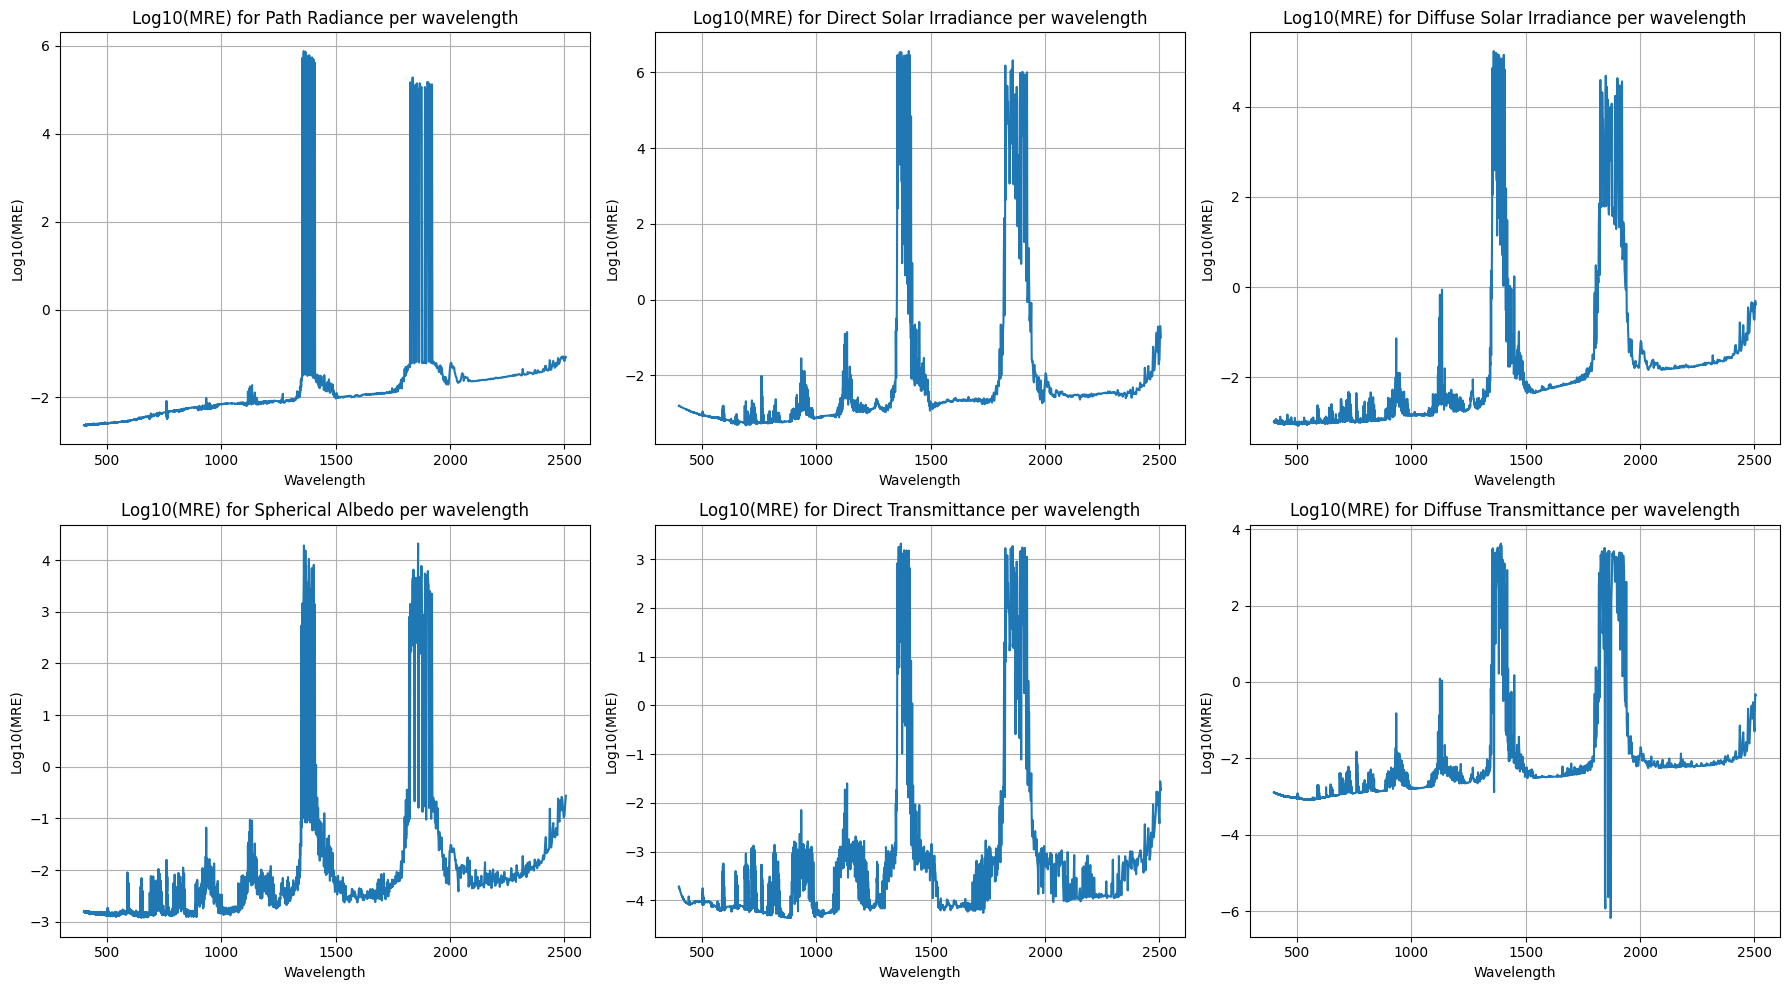

In [107]:
mre = utils.mre_score(Y_test, Y_test_pred, wavelengths)
print("Testing MRE:", mre)

mre_per_func = utils.mre_score(Y_test, Y_test_pred, wavelengths, axis=2)
for i in range(globals.N_FUNCTIONS):
    print(f"{function_names_plots[i]} MRE: {mre_per_func[i]:.4f}")

mre_per_wvl = utils.mre_score(Y_test, Y_test_pred, wavelengths, axis=1)
fig, axes = plt.subplots(1, 2, figsize=(20, 5))
axes[0].plot(wavelengths, mre_per_wvl)
axes[0].set_xlabel("Wavelength")
axes[0].set_ylabel("MRE")
axes[0].set_title("MRE per Wavelength")
axes[0].grid()
axes[1].plot(wavelengths, mre_per_wvl)
axes[1].set_ylim(0, 0.6)
axes[1].set_xlabel("Wavelength")
axes[1].set_ylabel("MRE")
axes[1].set_title("MRE per Wavelength (Zoomed)")
axes[1].grid()
plt.tight_layout()
plt.show()

# MRE per wavelength again but in log scale to better visualize small values
mre_per_wvl_log = utils.mre_score(Y_test, Y_test_pred, wavelengths, axis=1)
mre_per_wvl_log = np.log10(mre_per_wvl_log + 1e-10)  # add small value to avoid log(0)
plt.figure(figsize=(10, 6))
plt.plot(wavelengths, mre_per_wvl_log)
plt.xlabel("Wavelength")
plt.ylabel("Log10(MRE)")
plt.title("Log10(MRE) per Wavelength")
plt.grid()
plt.tight_layout()
plt.show()

mre_per_func_wvl = utils.mre_score(Y_test, Y_test_pred, wavelengths, axis=0)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for i in range(globals.N_FUNCTIONS):
    axes[i].plot(wavelengths, mre_per_func_wvl[i])
    axes[i].set_ylim(0, 1.25)
    axes[i].set_xlabel("Wavelength")
    axes[i].set_ylabel("MRE")
    axes[i].set_title(f"MRE for {function_names_plots[i]} per wavelength")
    axes[i].grid()
plt.tight_layout()
plt.show()

# MRE per function again but in log scale to better visualize small values
mre_per_func_wvl_log = utils.mre_score(Y_test, Y_test_pred, wavelengths, axis=0)
mre_per_func_wvl_log = np.log10(mre_per_func_wvl_log + 1e-10)  # add small value to avoid log(0)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for i in range(globals.N_FUNCTIONS):
    axes[i].plot(wavelengths, mre_per_func_wvl_log[i])
    axes[i].set_xlabel("Wavelength")
    axes[i].set_ylabel("Log10(MRE)")
    axes[i].set_title(f"Log10(MRE) for {function_names_plots[i]} per wavelength")
    axes[i].grid()
plt.tight_layout()
plt.show()

Testing MAE: 0.16865751
Path Radiance MAE: 0.0602
Direct Solar Irradiance MAE: 0.6689
Diffuse Solar Irradiance MAE: 0.2823
Spherical Albedo MAE: 0.0002
Direct Transmittance MAE: 0.0001
Diffuse Transmittance MAE: 0.0002


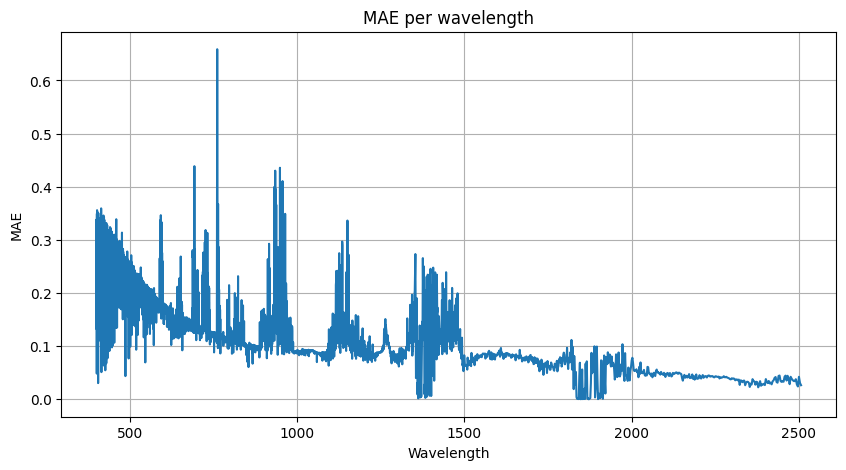

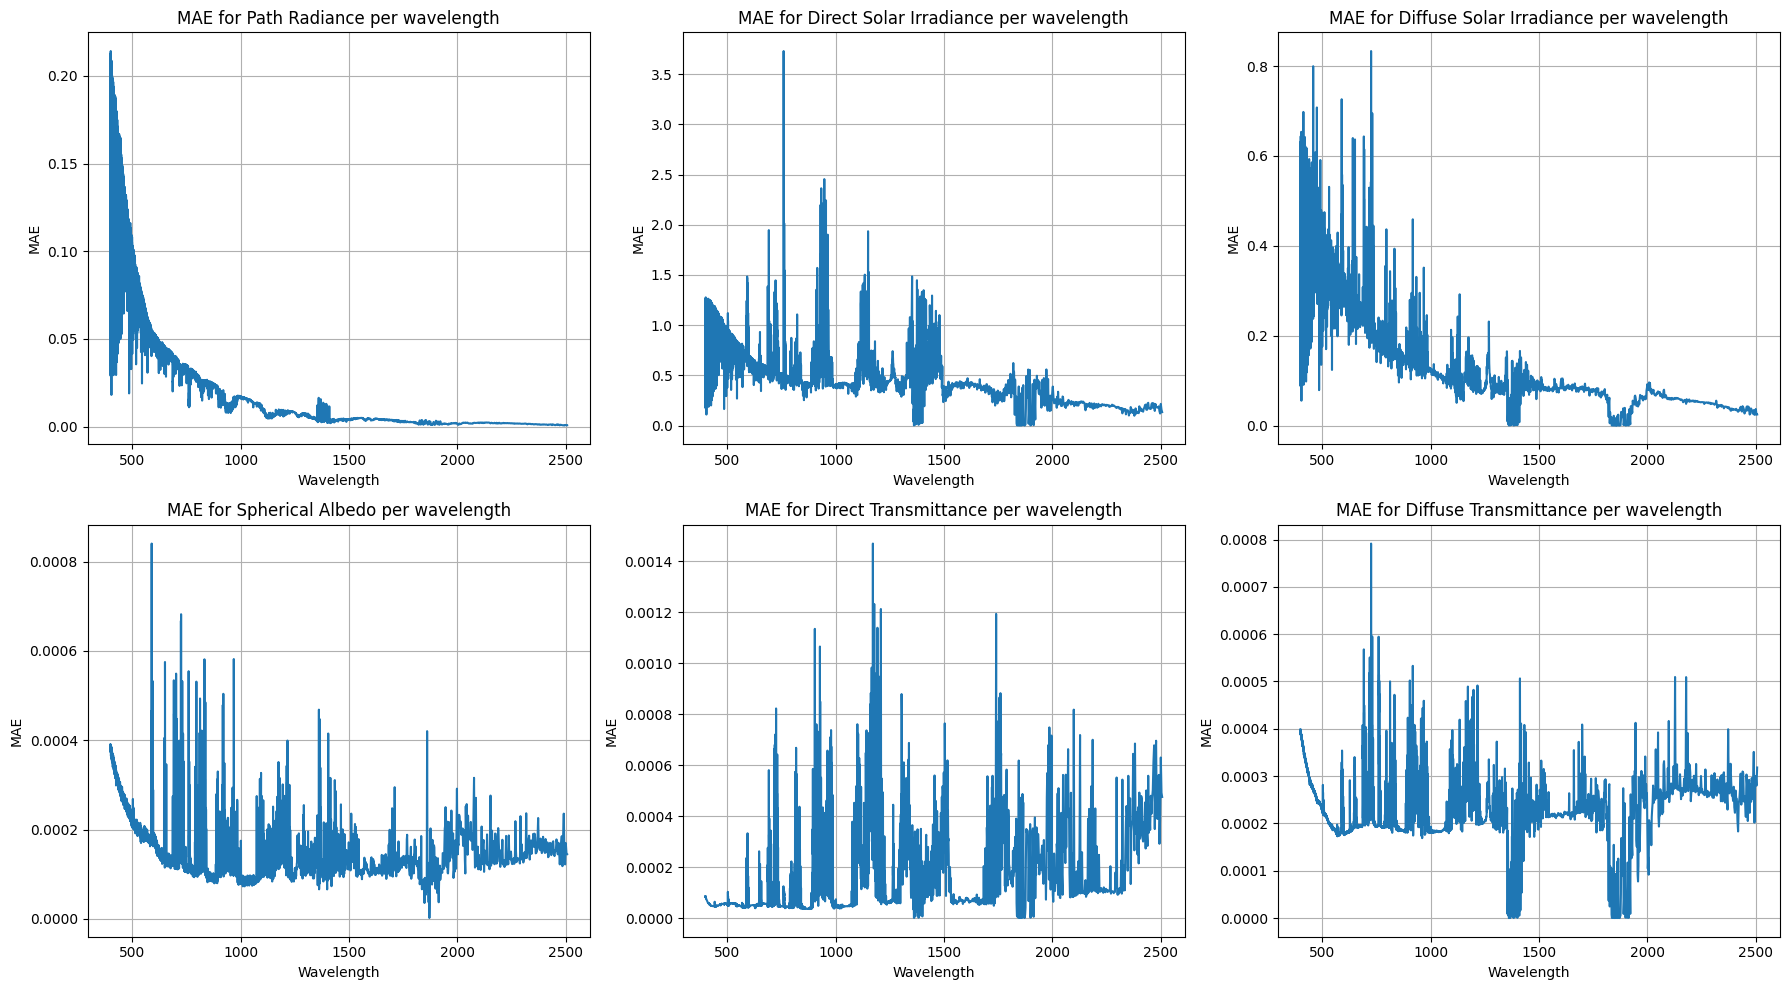

In [14]:
mae = utils.mae_score(Y_test, Y_test_pred, wavelengths)
print("Testing MAE:", mae)

mae_per_func = utils.mae_score(Y_test, Y_test_pred, wavelengths, axis=2)
for i in range(globals.N_FUNCTIONS):
    print(f"{function_names_plots[i]} MAE: {mae_per_func[i]:.4f}")

mae_per_wvl = utils.mae_score(Y_test, Y_test_pred, wavelengths, axis=1)
plt.figure(figsize=(10, 5))
plt.plot(wavelengths, mae_per_wvl)
plt.xlabel("Wavelength")
plt.ylabel("MAE")
plt.title("MAE per wavelength")
plt.grid()
plt.show()

mae_per_func_wvl = utils.mae_score(Y_test, Y_test_pred, wavelengths, axis=0)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for i in range(globals.N_FUNCTIONS):
    axes[i].plot(wavelengths, mae_per_func_wvl[i])
    axes[i].set_xlabel("Wavelength")
    axes[i].set_ylabel("MAE")
    axes[i].set_title(f"MAE for {function_names_plots[i]} per wavelength")
    axes[i].grid()
plt.tight_layout()
plt.show()

Global Coverage Probability (2σ): 97.84%
------------------------------
Path Radiance   Coverage: 97.72%
Direct Solar Irradiance Coverage: 98.09%
Diffuse Solar Irradiance Coverage: 96.50%
Spherical Albedo Coverage: 98.46%
Direct Transmittance Coverage: 98.23%
Diffuse Transmittance Coverage: 98.06%


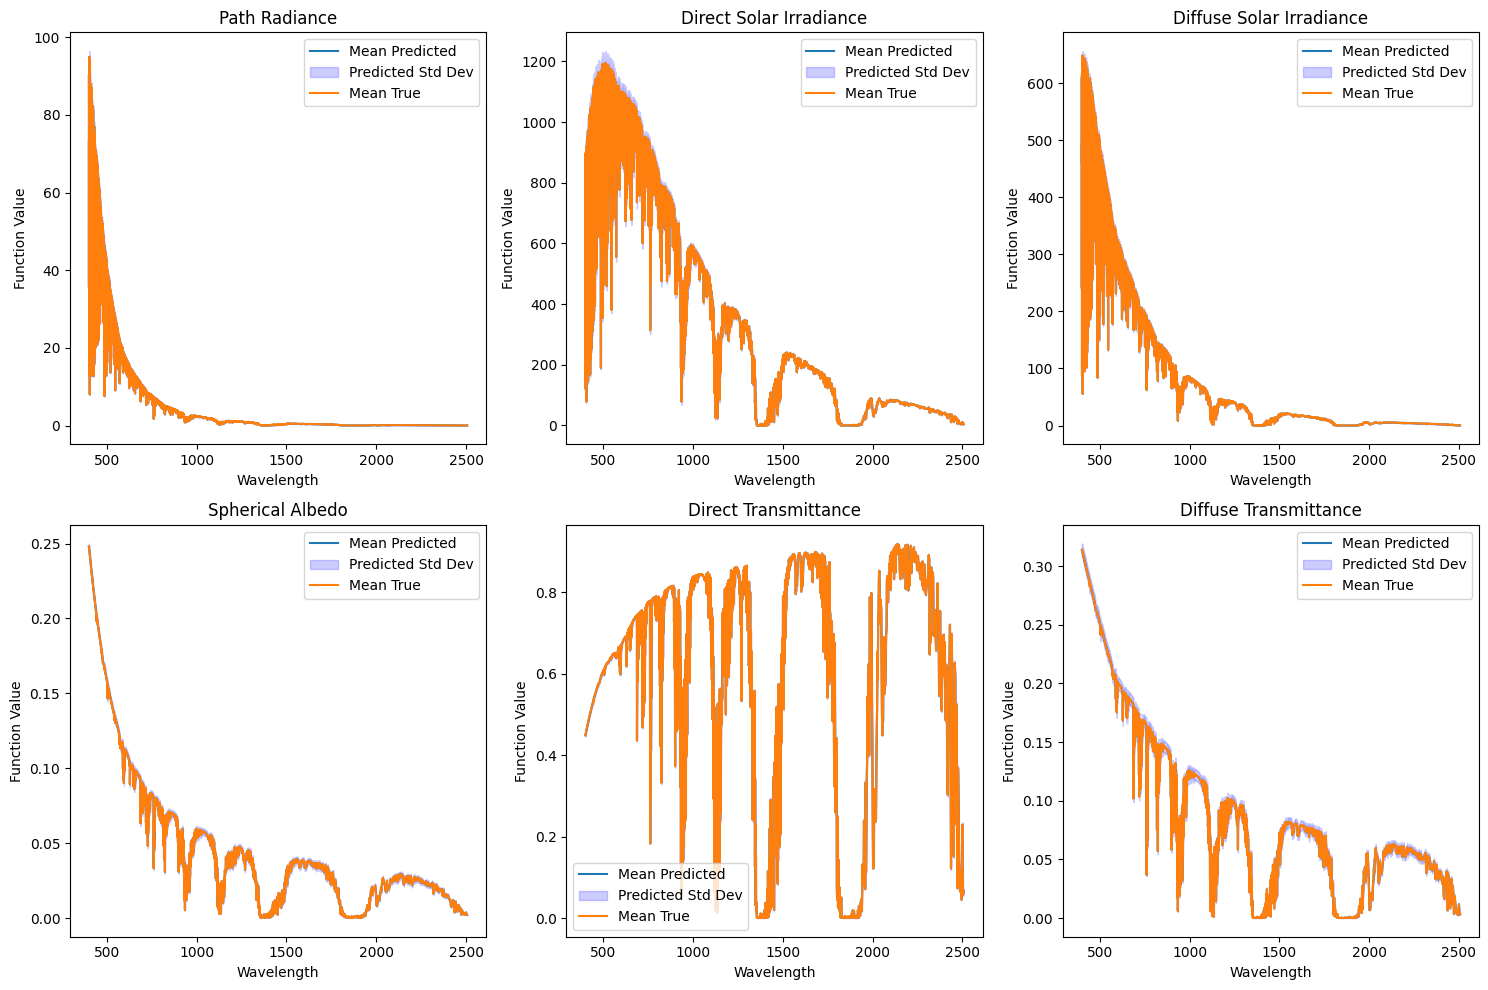

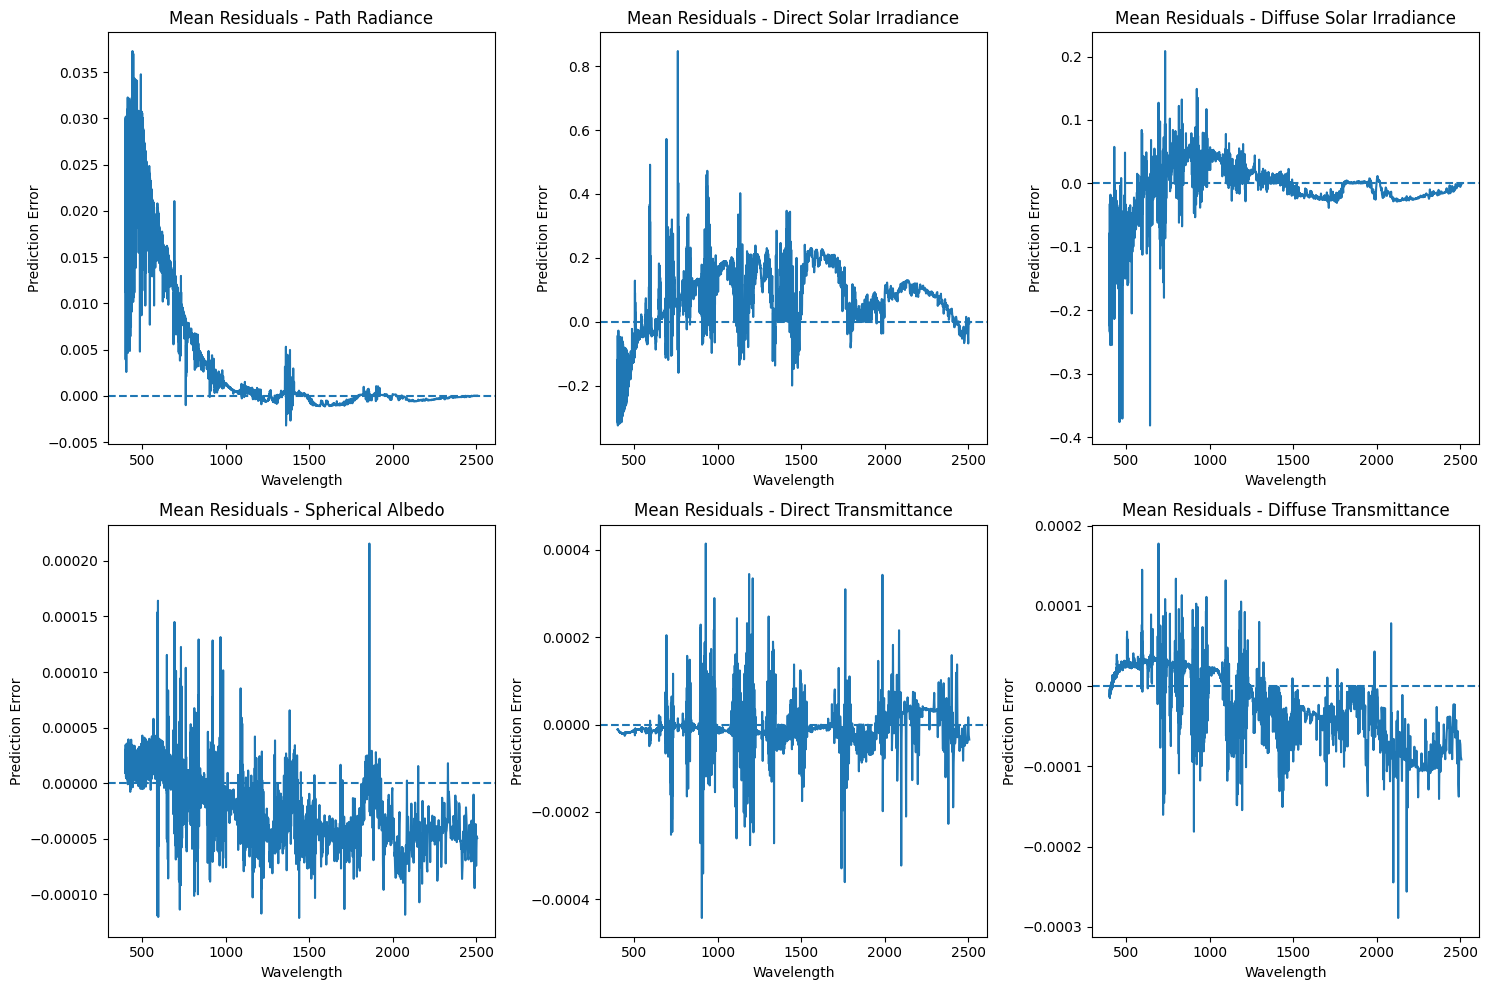

In [15]:
# --- coverage probability ---
global_cov, func_cov = utils.calculate_coverage(Y_test, Y_test_pred, Y_test_std)
print(f"Global Coverage Probability ({2}σ): {global_cov:.2f}%")
print("-" * 30)
for i, name in enumerate(function_names_plots):
    print(f"{name:15} Coverage: {func_cov[i]:.2f}%")


# --- compute mean true and predicted functions across all samples ---
Y_true_mean = np.mean(Y_test, axis=0)        # shape: (6, 4205)
Y_pred_mean = np.mean(Y_test_pred, axis=0)       # shape: (6, 4205)
Y_std_mean = np.mean(Y_test_std, axis=0)        # shape: (6, 4205)

# plot mean true vs predicted
plt.figure(figsize=(15, 10))

for i in range(globals.N_FUNCTIONS):  # iterate over functions
    plt.subplot(2, 3, i + 1)

    plt.plot(wavelengths, Y_pred_mean[i], label="Mean Predicted")
    # with Gaussian prior, 2 standard deviations should cover ~95% of the true function values
    plt.fill_between(wavelengths, Y_pred_mean[i] - 2 * Y_std_mean[i], Y_pred_mean[i] + 2 * Y_std_mean[i], color="blue", alpha=0.2, label="Predicted Std Dev")
    plt.plot(wavelengths, Y_true_mean[i], label="Mean True")

    plt.title(f"{function_names_plots[i]}")
    plt.xlabel("Wavelength")
    plt.ylabel("Function Value")
    plt.legend()

plt.tight_layout()
plt.show()


# --- residuals for all samples ---
residuals = Y_test_pred - Y_test   # shape: (n_samples, 6, 4205)

# mean residual across samples
mean_residuals = np.mean(residuals, axis=0)  # shape: (6, 4205)

plt.figure(figsize=(15, 10))

for i in range(globals.N_FUNCTIONS):
    plt.subplot(2, 3, i + 1)

    plt.plot(wavelengths, mean_residuals[i])
    plt.axhline(0, linestyle="--")

    plt.title(f"Mean Residuals - {function_names_plots[i]}")
    plt.xlabel("Wavelength")
    plt.ylabel("Prediction Error")

plt.tight_layout()
plt.show()

Load the test csv and apply the model to measure inference runtime.

In [16]:
X_test_csv = utils.load_test_csv(globals.CURRENT_TEST_FILE)
print(f"Test inputs from CSV shape: {X_test_csv.shape}")

# scale test inputs with the same scaler used for training
X_test_csv_scaled = best_5_x_scalers[idx].transform(X_test_csv)

# predict on test CSV with chosen model
Y_test_csv_pred = np.zeros((X_test_csv.shape[0], globals.N_FUNCTIONS, Y_tr.shape[2]))  # (n_samples, 6, 4205)
Y_test_csv_std = np.zeros((X_test_csv.shape[0], globals.N_FUNCTIONS, Y_tr.shape[2]))  # (n_samples, 6, 4205)
start_time_test_csv = time.time()
for i in range(globals.N_FUNCTIONS):
    Y_pred_red_scaled, Y_std_red_scaled = best_5_gpr_lists[idx][i].predict(X_test_csv_scaled, return_std=True) # predictions in reduced and scaled space

    # inverse predictions
    Y_pred_red = best_5_y_scalers[idx][i].inverse_transform(Y_pred_red_scaled)  # inverse scaling
    Y_pred = best_5_pca_lists[idx][i].inverse_transform(Y_pred_red)  # inverse PCA
    Y_test_csv_pred[:, i, :] = Y_pred

    # inverse std
    if str(best_5_y_scalers[idx][i]) == "StandardScaler()":
        Y_std_red = Y_std_red_scaled * best_5_y_scalers[idx][i].scale_
    else: # MinMaxScaler
        Y_std_red = Y_std_red_scaled * (best_5_y_scalers[idx][i].data_max_ - best_5_y_scalers[idx][i].data_min_)
    W = best_5_pca_lists[idx][i].components_ 
    latent_var = Y_std_red**2  # shape (n_samples, n_components)
    Y_var_full = latent_var @ (W**2) 
    Y_std_full = np.sqrt(Y_var_full)
    Y_test_csv_std[:, i, :] = Y_std_full

end_time_test_csv = time.time()
print(f"Time taken to predict on test CSV: {end_time_test_csv - start_time_test_csv:.2f} seconds")
print("Predictions on test CSV shape:", Y_test_csv_pred.shape)
print("Std on test CSV shape:", Y_test_csv_std.shape)

Test inputs from CSV shape: (10000, 9)
Time taken to predict on test CSV: 4.43 seconds
Predictions on test CSV shape: (10000, 6, 4205)
Std on test CSV shape: (10000, 6, 4205)


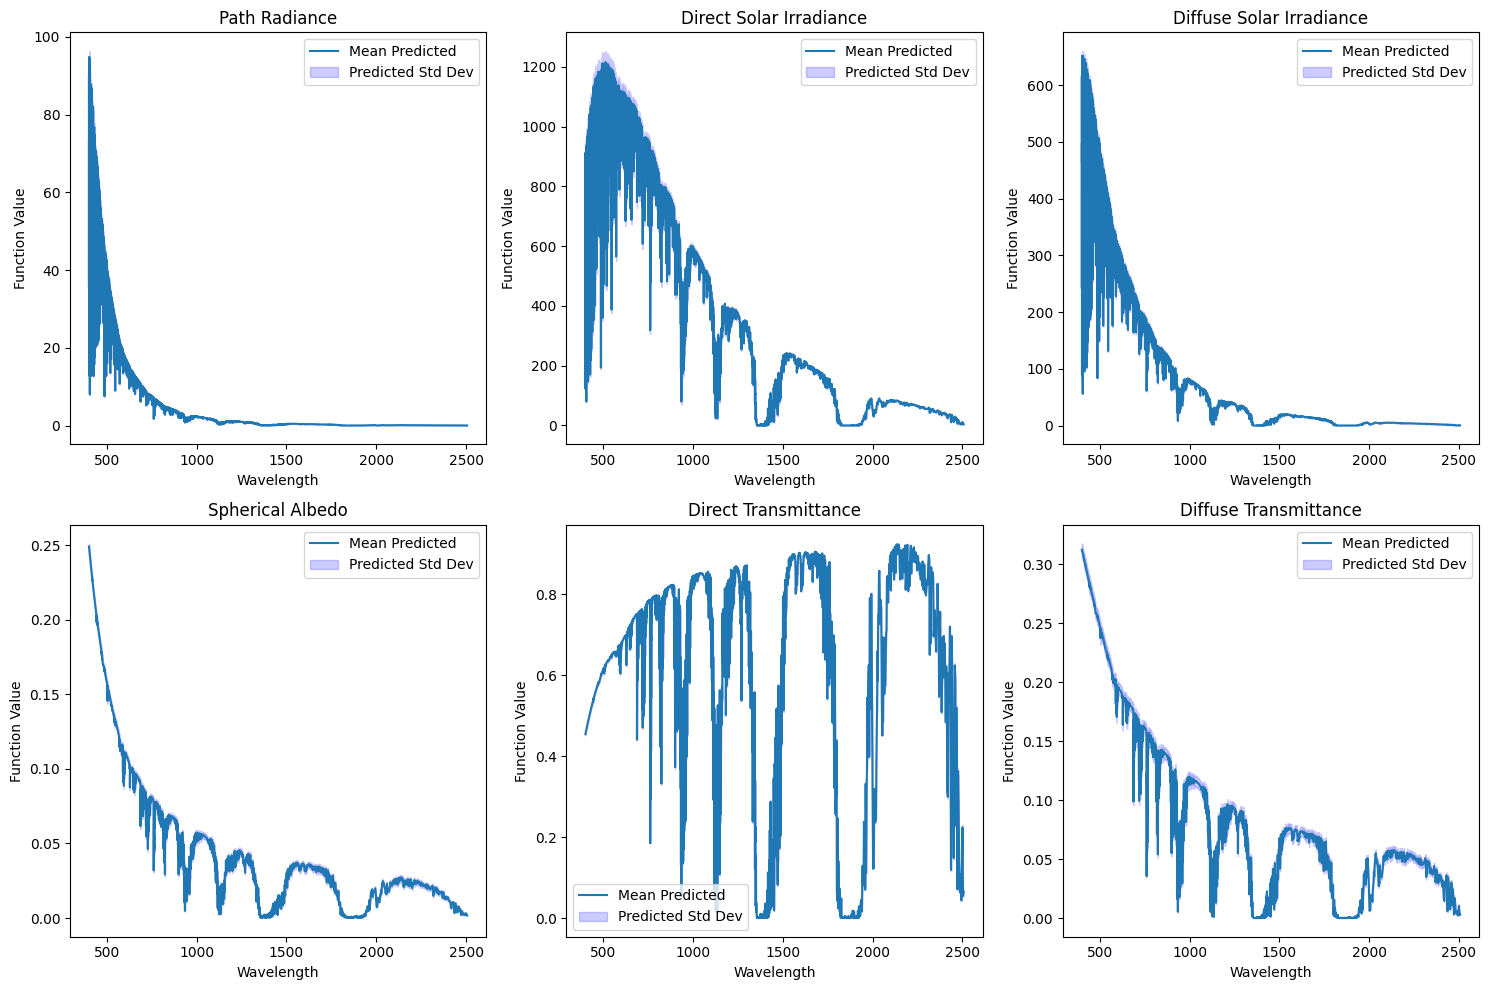

In [17]:
# compute mean predicted functions across all samples
Y_pred_mean = np.mean(Y_test_csv_pred, axis=0)
Y_std_mean = np.mean(Y_test_csv_std, axis=0)

plt.figure(figsize=(15, 10))

for i in range(globals.N_FUNCTIONS):
    plt.subplot(2, 3, i + 1)

    plt.plot(wavelengths, Y_pred_mean[i], label="Mean Predicted")
    plt.fill_between(wavelengths, Y_pred_mean[i] - 2 * Y_std_mean[i], Y_pred_mean[i] + 2 * Y_std_mean[i], color="blue", alpha=0.2, label="Predicted Std Dev")

    plt.title(f"{function_names_plots[i]}")
    plt.xlabel("Wavelength")
    plt.ylabel("Function Value")
    plt.legend()

plt.tight_layout()
plt.show()